## Global configuration

In [35]:
dataset_root = "../datasets"

import sys
sys.path.append("../src/")  # analytics package

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Dataset loading and preparation

In [36]:
import pyarrow.compute as pc
from tls_profiling.preprocessing import build_and_fit_preprocessor, extract_features
from tls_profiling.io import open_tls_parquet_dataset

dataset = open_tls_parquet_dataset(f"{dataset_root}/malware.parquet")

filt = (
    pc.starts_with(
        pc.field("meta.sample.id"), "25090"
    )  # use meta.sample.id to get only a single day 2025-09-01
)

print(f"Loading dataset...filter={filt}")
df = dataset.to_table(filter=filt).to_pandas()

df.head(10)

Loading dataset...filter=starts_with(meta.sample.id, {pattern="25090", ignore_case=false})


,bs,ps,br,pr,dp,sp,da,sa,ts,td,...,tls.ja4,tls.ja3s,tls.ja4s,meta.sample.id,meta.malware.family,meta.system.os,meta.system.service,meta.application.name,meta.application.process,tls.rec
0,1262,13,8316,12,443,49792,20.72.205.209,10.127.0.189,1.756762e+09,0.941528,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -2..."
1,49974,64,39987,54,443,49801,40.126.31.67,10.127.0.189,1.756762e+09,128.561234,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,None,None,None,"[-226, 3954, -102, -1, -40, 1, 40, -445, -3616..."
2,35832,48,31235,40,443,49803,40.126.31.67,10.127.0.189,1.756762e+09,138.264477,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,None,None,None,"[-226, 3954, -102, -1, -40, 1, 40, -469, -7637..."
3,4529,14,8280,14,443,49804,20.72.205.209,10.127.0.189,1.756762e+09,1.195099,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
4,4035,14,4910,13,443,49806,52.167.17.97,10.127.0.189,1.756762e+09,0.749950,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
5,1982,13,4870,12,443,49807,52.167.17.97,10.127.0.189,1.756762e+09,0.683508,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -9..."
6,2437,19,21862,25,443,49808,52.167.17.97,10.127.0.189,1.756762e+09,0.657093,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
7,1775,25,28988,27,443,49860,74.178.76.128,10.127.0.189,1.756762e+09,0.216118,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_core,None,None,"[-206, 2488, -102, -1, -40, 1, 40, -82, -264, ..."
8,1134,13,3326,10,443,49861,13.95.31.18,10.127.0.189,1.756762e+09,0.235395,...,t12d1909h2_d83cc789557e_7af1ed941c26,87b9bed0515be16c82bdc44d88a4a0ec,t1204h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_delivery,None,None,"[-211, 2550, -102, -1, -40, 1, 40, 64, -82, -9..."
9,996,10,3239,8,443,49862,74.178.76.128,10.127.0.189,1.756762e+09,0.173583,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_core,None,None,"[-206, 2487, -102, -1, -40, 1, 40, -82, -85, 5..."


## Preprocessing & Data Partitioning

In [37]:
VAL_RATIO = 0.2
TEST_RATIO = 0.2
ENCODING_DIM = 10
NUM_NODES = 5
TRAINING_ROUNDS = 10
TARGET_FAMILY = "ades_stealer"

import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tls_profiling.preprocessing.malware_families import get_families, per_family_split


# Get the first family and its data
families = get_families(df)
splits = per_family_split(df, families, test_size=TEST_RATIO)
pre_train_df, test_df = splits[TARGET_FAMILY]

# Preprocess the entire family data to establish the feature space
pipeline = build_and_fit_preprocessor(extract_features(pre_train_df))
X_train_full = pipeline.transform(extract_features(pre_train_df))
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = np.clip(scaler.fit_transform(X_train_full), 0, 1)

# Shuffle and split the training data into NUM_NODES partitions
indices = np.random.permutation(len(X_train_scaled))
partitions = np.array_split(X_train_scaled[indices], NUM_NODES)

## The Flower Client Class

In [38]:
from flwr.common import Scalar
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from flwr.client import NumPyClient
from collections import OrderedDict
from tls_profiling.autoencoder.models_torch import Net
from tls_profiling.autoencoder.train_torch import train_autoencoder, evaluate_model

input_dim: int = X_train_scaled.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SingleFamilyClient(NumPyClient):
    def __init__(self, data_partition, device):
        self.device = device
        self.model = Net(input_dim=input_dim, encoding_dim=ENCODING_DIM).to(device)
        self.criterion = nn.BCELoss()

        # Split node's local partition into train/val
        split_idx = int((1 - VAL_RATIO) * len(data_partition))
        self.x_train = data_partition[:split_idx]
        self.x_val = data_partition[split_idx:]

        # x_train and x_val tensors should be copied by x_*.copy() to enable writing (not required) and fix Ray backend UserWarning: The given NumPy array is not writable ...
        # wont do that as there qould be memory overhead (sharing the tensors by default is mroe memory efficient)
        self.train_loader = DataLoader(
            TensorDataset(torch.as_tensor(self.x_train).float()),
            batch_size=16,
            shuffle=True,
        )
        self.val_loader = DataLoader(
            TensorDataset(torch.as_tensor(self.x_val).float()), batch_size=16
        )

    def get_parameters(self, config):
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def set_parameters(self, parameters):
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        _ = self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        history = train_autoencoder(
            self.model, self.x_train, self.x_val, max_epochs=1, device=self.device
        )
        last_loss = (
            history["loss"][-1] if "loss" in history and history["loss"] else 0.0
        )
        num_examples = len(self.x_train)
        metrics: dict[str, Scalar] = {"train_loss": float(last_loss)}
        return self.get_parameters(config={}), num_examples, metrics

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss = evaluate_model(self.model, self.val_loader, self.criterion, self.device)
        num_examples = len(self.x_val)
        metrics: dict[str, Scalar] = {"mse": float(loss)}
        return loss, num_examples, metrics

## The Simulation Setup

In [39]:
from flwr.client import ClientApp
from flwr.common import Context, parameters_to_ndarrays
from flwr.server import ServerApp, ServerAppComponents, ServerConfig, strategy
from flwr.simulation import run_simulation

# Global store for federated fit/eval histories
# as the run_simulation() is not returning the history with metrics, we will provide the recording strategy to build the history incrementaly
fed_fit_history = []
fed_eval_history = []

# Global storage for models
# Key: family_name, Value: list of numpy arrays (weights)
trained_global_models = {}


class RecordingStrategy(strategy.FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        params, metrics = super().aggregate_fit(server_round, results, failures)
        if metrics:
            fed_fit_history.append((server_round, params, metrics))
        if params is not None and server_round == TRAINING_ROUNDS:
            ndarrays = parameters_to_ndarrays(params)
            trained_global_models[TARGET_FAMILY] = ndarrays
            print(f"Final weights for {TARGET_FAMILY} captured in global memory.")
        return params, metrics

    def aggregate_evaluate(self, server_round, results, failures):
        loss, metrics = super().aggregate_evaluate(server_round, results, failures)
        if metrics:
            fed_eval_history.append((server_round, loss, metrics))
        return loss, metrics


def aggregate_weighted_average(metrics):
    total_examples = sum(num for num, _ in metrics)
    combined_results: dict[str, Scalar] = {}
    all_keys = metrics[0][1].keys()
    for key in all_keys:
        weighted_sum = sum(num * float(m[key]) for num, m in metrics)
        combined_results[key] = float(weighted_sum / total_examples)
    return combined_results


def client_fn(context: Context):
    p_id = int(context.node_config["partition-id"])
    return SingleFamilyClient(partitions[p_id], device).to_client()


def server_fn(context: Context):
    fl_strategy = RecordingStrategy(
        fraction_fit=1.0,  # Train on 100% of nodes in each training round
        min_fit_clients=NUM_NODES,  # Wait for all nodes to start training
        fraction_evaluate=1.0,  # Evaluate on 100% of nodes
        min_evaluate_clients=NUM_NODES,  # Wait for all nodes to evaluate
        min_available_clients=NUM_NODES,  # Minimum number of available clients needed to start a round
        fit_metrics_aggregation_fn=aggregate_weighted_average,  # From the training data on the nodes, how the nodes are actually learning locally
        evaluate_metrics_aggregation_fn=aggregate_weighted_average,  # From the validation data, how the "Global Model" is performing after the weights have been averaged
    )
    server_config = ServerConfig(num_rounds=TRAINING_ROUNDS)
    return ServerAppComponents(strategy=fl_strategy, config=server_config)


client_app = ClientApp(client_fn=client_fn)
server_app = ServerApp(server_fn=server_fn)

print(
    f"Starting Federated Learning for {TARGET_FAMILY} across {NUM_NODES} nodes in {TRAINING_ROUNDS} rounds..."
)
# https://flower.ai/docs/framework/1.27/en/how-to-run-simulations.html#simulation-in-colab-jupyter
run_simulation(
    server_app=server_app,
    client_app=client_app,
    num_supernodes=NUM_NODES,
    backend_config={
        "client_resources": {
            "num_cpus": 2,  # Each virtual client gets 2 CPU cores
            "num_gpus": 0.2  # Each virtual client gets 20% of your GPU if available
            if torch.cuda.is_available()
            else 0,
        }
    },
)

INFO :      Starting Flower ServerApp, config: num_rounds=10, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client


Starting Federated Learning for ades_stealer across 5 nodes in 10 rounds...


(pid=1183391) 2026-03-25 14:26:48.113187: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(pid=1183391) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
(pid=gcs_server) [2026-03-25 14:27:00,173 E 1182171 1182171] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(pid=1183390) 2026-03-25 14:26:49.022559: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations. [repeated 7x across cluster]
(pid=1183390) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate com

Final weights for ades_stealer captured in global memory.


INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 7.62s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.46769851446151733
INFO :      		round 2: 0.16699379980564116
INFO :      		round 3: 0.08538606762886047
INFO :      		round 4: 0.07309095710515975
INFO :      		round 5: 0.0673733927309513
INFO :      		round 6: 0.06207658648490906
INFO :      		round 7: 0.05784721300005913
INFO :      		round 8: 0.05535717755556106
INFO :      		round 9: 0.05420217365026474
INFO :      		round 10: 0.052957183122634886
INFO :      	History (metrics, distributed, fit):
INFO :      	{'train_loss': [(1, 0.6274320056833786),
INFO :      	                (2, 0.31300357274234664),
INFO :      	                (3, 0.1182889490750427),
INFO :      	                (4, 0.07905714843162859),
INFO :      	                (5, 0.07096674456880399),
INFO :      	                (6, 0.06501289951785277),
IN

## History Visualisation

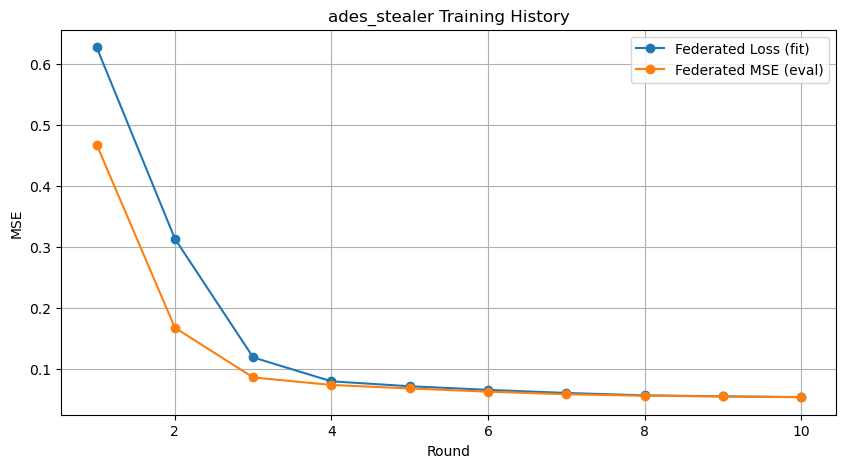

In [40]:
import matplotlib.pyplot as plt

rounds = [item[0] for item in fed_eval_history]
losses = [item[1] for item in fed_eval_history]
train_losses = [item[2]["train_loss"] for item in fed_fit_history]
mses = [item[2]["mse"] for item in fed_eval_history]

plt.figure(figsize=(10, 5))
plt.plot(rounds, train_losses, marker="o", label="Federated Loss (fit)")
plt.plot(rounds, mses, marker="o", label="Federated MSE (eval)")
plt.title(f"{TARGET_FAMILY} Training History")
plt.xlabel("Round")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.show()

## Global Model Evaluation for the Same Family

In [49]:
# Get the global model from our global dictionary
eval_model = Net(input_dim=input_dim, encoding_dim=10).to(device)
weights = trained_global_models[TARGET_FAMILY]
params_dict = zip(eval_model.state_dict().keys(), weights)
state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
eval_model.load_state_dict(state_dict)
eval_model.eval()

# Prepare test data
X_test_raw = pipeline.transform(extract_features(test_df))
X_test_scaled = np.clip(scaler.transform(X_test_raw), 0, 1)

# Evaluate the global model
final_test_loss = evaluate_model(
    model=eval_model, data_loader=X_test_scaled, criterion=nn.BCELoss(), device=device
)

print(f"Final Evaluation of {TARGET_FAMILY}:")
print(f"   - Training/Val Loss (last FL round): {mses[-1]:.6f}")
print(f"   - Independent Test Loss (test_df):  {final_test_loss:.6f}")

Final Evaluation of ades_stealer:
   - Training/Val Loss (last FL round): 0.052957
   - Independent Test Loss (test_df):  0.047564


## Global Model Evaluation for Other Families

In [ ]:
import pandas as pd
from tls_profiling.autoencoder.train_torch import compute_recon_error

# Define threshold based on successful reconstructions from (greater than) errors on the "Known" test set (test_df of the target family)
target_errors = compute_recon_error(
    eval_model, X_test_scaled, nn.BCELoss(), device=device
)
mean_error = np.mean(target_errors)
std_error = np.std(target_errors)
fixed_threshold = mean_error + (2 * std_error)

print(f"Statistics for {TARGET_FAMILY} model:")
print(f"  Mean Reconstruction Error: {mean_error:.6f}")
print(f"  Detection Threshold:       {fixed_threshold:.6f}")


results = []

for family_name in splits.keys():
    # Load test data for the current family in the loop
    _, current_test_df = splits[family_name]

    # Preprocess
    X_raw = pipeline.transform(extract_features(current_test_df))
    X_scaled = np.clip(scaler.transform(X_raw), 0, 1)

    # Get individual errors for this family's data using the Target Model
    current_errors = compute_recon_error(eval_model, X_scaled, nn.BCELoss(), device)

    # Logic check:
    # If it's the target family -> errors ABOVE threshold are False Negatives
    # If it's any other family -> errors BELOW threshold are False Positives

    if family_name == TARGET_FAMILY:
        fn_count = np.sum(current_errors > fixed_threshold)
        fn_rate = (fn_count / len(current_errors)) * 100
        results.append(
            {
                "Family": family_name,
                "Type": "Target (FN Check)",
                "Count": fn_count,
                "Rate (%)": round(fn_rate, 2),
                "Status": "False Negatives",
            }
        )
    else:
        fp_count = np.sum(current_errors <= fixed_threshold)
        fp_rate = (fp_count / len(current_errors)) * 100
        results.append(
            {
                "Family": family_name,
                "Type": "Stranger (FP Check)",
                "Count": fp_count,
                "Rate (%)": round(fp_rate, 2),
                "Status": "False Positives",
            }
        )

# Display as a clean DataFrame
report_df = pd.DataFrame(results)
print(report_df.to_string(index=False))

Statistics for ades_stealer model:
  Mean Reconstruction Error: 0.047564
  Detection Threshold:       0.095191


/home/rychly/repos/AutoFedProfile/notebooks/../src/tls_profiling/preprocessing/extract_features.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str)
/home/rychly/repos/AutoFedProfile/notebooks/../src/tls_profiling/preprocessing/extract_features.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str)
/home/rychly/repos/AutoFedProfile/notebooks/../src/tls_profiling/preprocessing/extract_features.py:109: FutureWarning:

        Family                Type  Count  Rate (%)          Status
  ades_stealer   Target (FN Check)     21      3.79 False Negatives
    agenttesla Stranger (FP Check)     67     57.76 False Positives
        amadey Stranger (FP Check)   5395     72.18 False Positives
      asyncrat Stranger (FP Check)   2136     67.51 False Positives
       aurotun Stranger (FP Check)     17     50.00 False Positives
       azorult Stranger (FP Check)     61     50.00 False Positives
    babylonrat Stranger (FP Check)      8     33.33 False Positives
        berbew Stranger (FP Check)     14     87.50 False Positives
     blackmoon Stranger (FP Check)     88     48.35 False Positives
  blankgrabber Stranger (FP Check)     54     51.92 False Positives
 blihanstealer Stranger (FP Check)     30     83.33 False Positives
         chaos Stranger (FP Check)    533     96.21 False Positives
  cobaltstrike Stranger (FP Check)    711     97.13 False Positives
    coffloader Stranger (FP Check)     40     71